# Tesla Deliveries & Production: End-to-End ML Pipeline (2015–2025)
This notebook builds a complete ML pipeline on the Tesla deliveries/production/pricing dataset: data loading, cleaning, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series analysis/forecasting.

# Setup
Run this cell first. On Kaggle, all required packages are normally pre-installed, so this just double-checks and installs anything missing.

In [1]:
import sys, subprocess

required = ['numpy', 'pandas', 'seaborn', 'matplotlib', 'scikit-learn', 'statsmodels']
for pkg in required:
    try:
        __import__(pkg if pkg != 'scikit-learn' else 'sklearn')
    except ImportError:
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        except Exception as e:
            print(f"Could not auto-install {pkg} ({e}). It may already be available, or you can install it manually.")

print("Setup check complete.")

Setup check complete.


# Loading the Dataset

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

CSV_FILENAME = 'tesla_deliveries_dataset_2015_2025.csv'

# On Kaggle, uploaded datasets live under /kaggle/input/<dataset-slug>/...
# rather than the notebook's working directory, so search there too.
candidate_paths = [
    CSV_FILENAME,
    os.path.join(os.getcwd(), CSV_FILENAME),
]

if os.path.isdir('/kaggle/input'):
    for dirpath, _, filenames in os.walk('/kaggle/input'):
        if CSV_FILENAME in filenames:
            candidate_paths.append(os.path.join(dirpath, CSV_FILENAME))

csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if csv_path is None:
    print("Could not auto-locate the CSV. Files currently visible under /kaggle/input:")
    if os.path.isdir('/kaggle/input'):
        for dirpath, _, filenames in os.walk('/kaggle/input'):
            for f in filenames:
                print(' -', os.path.join(dirpath, f))
    raise FileNotFoundError(
        f"Could not find '{CSV_FILENAME}'. On Kaggle: click 'Add Data' (top right) and "
        f"attach the dataset containing this CSV, then re-run this cell. You can also set "
        f"csv_path manually to one of the paths printed above."
    )

print("Loading CSV from:", csv_path)
df = pd.read_csv(csv_path)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nDescribe:")
df.describe()

Loading CSV from: tesla_deliveries_dataset_2015_2025.csv
Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


The dataset contains Tesla delivery, production, pricing, battery, range, CO2 savings, and charging infrastructure information from 2015–2025 across multiple regions (Europe, Asia, North America, Middle East) and vehicle models (Model S, Model X, Model 3, Model Y, Cybertruck).

# Missing Values and Duplicates

In [3]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Missing Values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows
0


The dataset was checked for missing values and duplicate records before analysis. No missing values or duplicate rows were found, so the data can proceed to EDA and modeling without imputation or de-duplication.

# EDA Chart Analysis

# Deliveries by Model

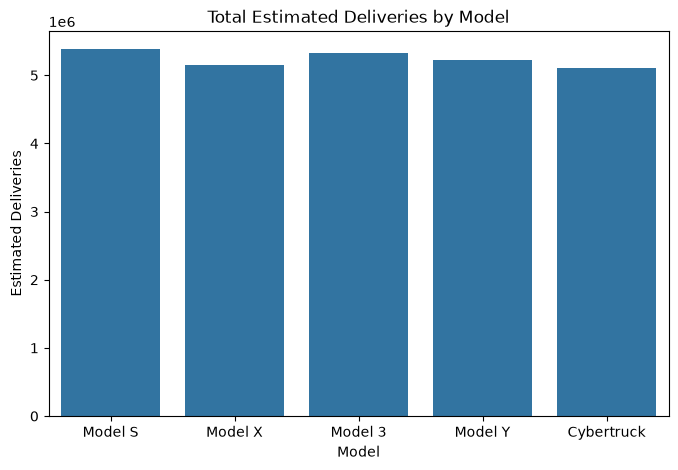

In [4]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Model',
    y='Estimated_Deliveries',
    estimator=sum,
    errorbar=None
)

plt.title("Total Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.show()

>The bar chart illustrates the distribution of estimated vehicle deliveries across different Tesla models. This visualization helps identify the most popular and frequently delivered models.

# Deliveries by Region

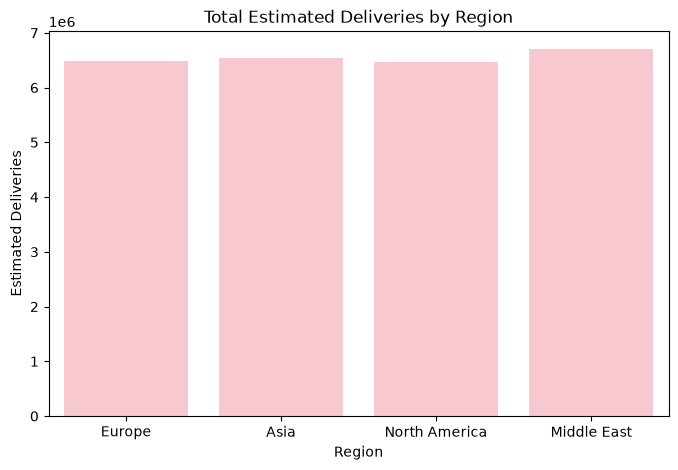

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Region',
    y='Estimated_Deliveries',
    estimator=sum,
    errorbar=None,
    color='pink'
)

plt.title("Total Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")

plt.show()

>The regional deliveries chart compares Tesla deliveries across different geographical regions. It provides insights into market demand and regional performance.

# Correlation Heatmap

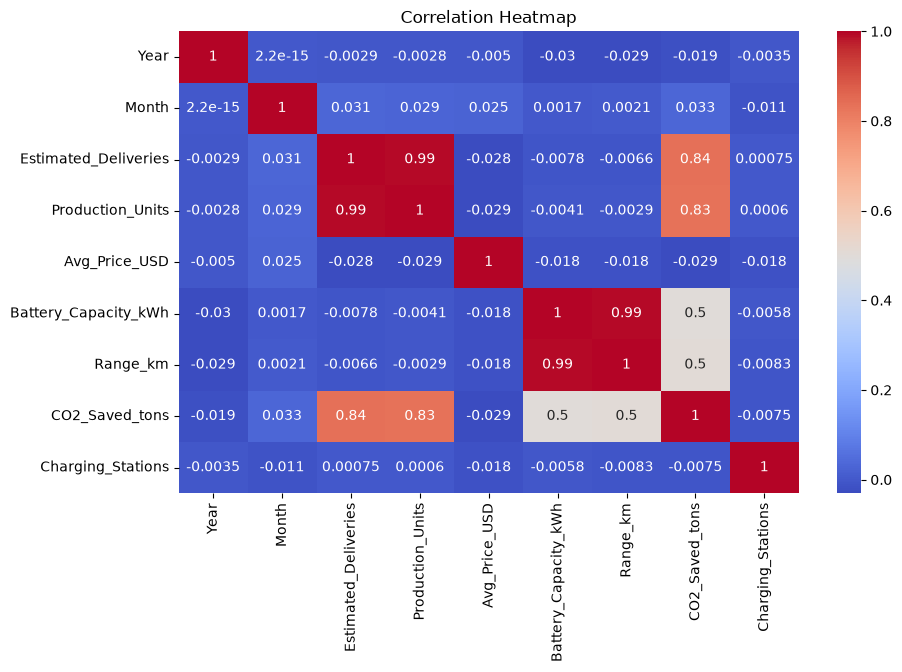

In [6]:
num_cols = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))

sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

>The correlation heatmap visualizes relationships among numerical variables. A strong positive correlation is observed between Production_Units and Estimated_Deliveries, indicating that higher production levels are associated with higher delivery volumes.

# Production vs Deliveries Scatter Plot

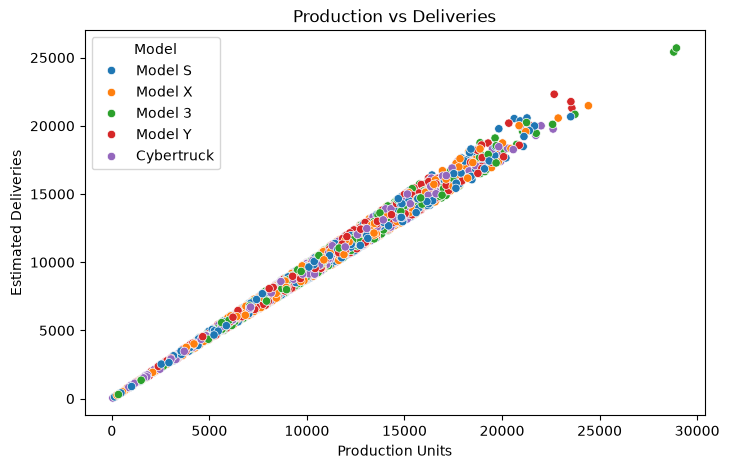

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Production_Units',
    y='Estimated_Deliveries',
    hue='Model'
)

plt.title("Production vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

>The scatter plot demonstrates the relationship between production units and estimated deliveries. The positive trend suggests that production volume is a strong predictor of deliveries across all models.

# Time Trend Line

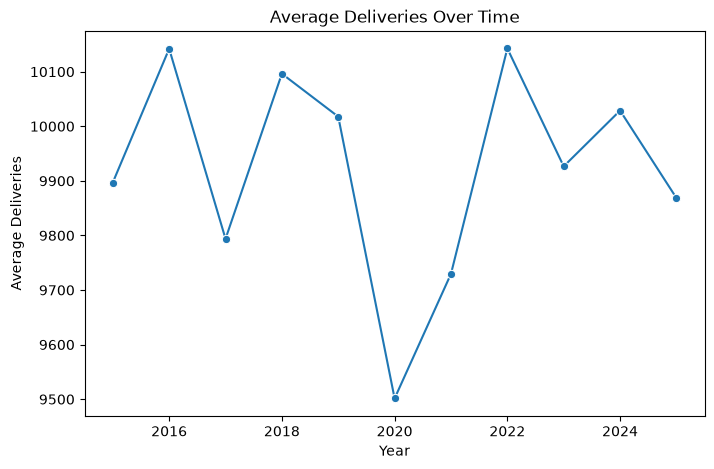

In [8]:
trend = df.groupby('Year')['Estimated_Deliveries'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=trend,
    x='Year',
    y='Estimated_Deliveries',
    marker='o'
)

plt.title("Average Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Average Deliveries")

plt.show()

>The line chart shows how average deliveries have changed over time. This visualization helps identify long-term growth patterns and delivery trends throughout the years from 2015 to 2025.

# Price and Battery Trends

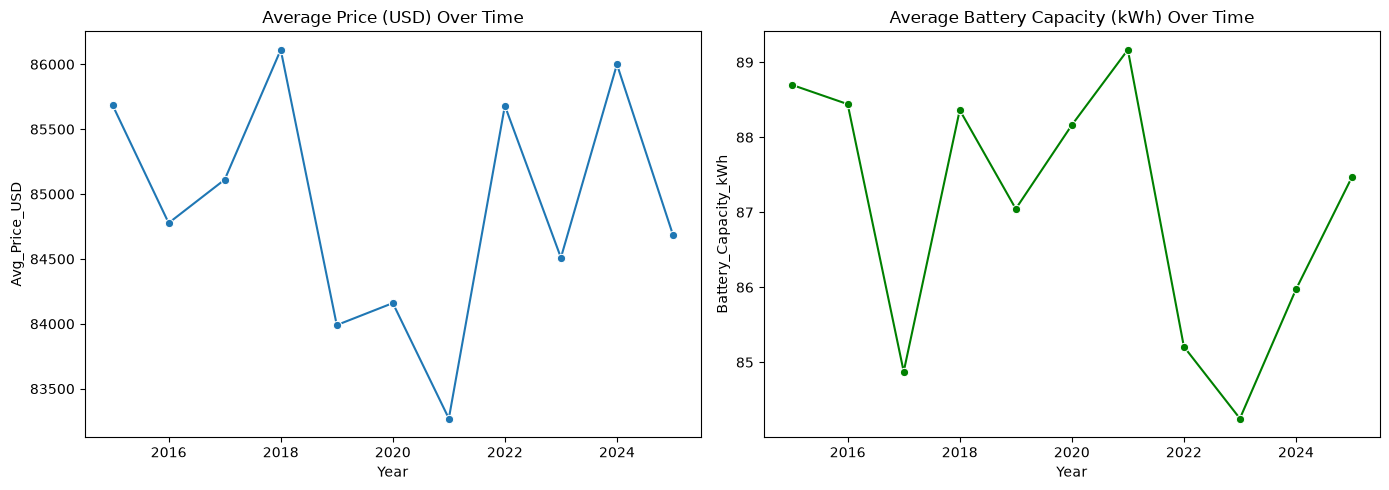

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

price_trend = df.groupby('Year')['Avg_Price_USD'].mean().reset_index()
sns.lineplot(data=price_trend, x='Year', y='Avg_Price_USD', marker='o', ax=axes[0])
axes[0].set_title('Average Price (USD) Over Time')

battery_trend = df.groupby('Year')['Battery_Capacity_kWh'].mean().reset_index()
sns.lineplot(data=battery_trend, x='Year', y='Battery_Capacity_kWh', marker='o', color='green', ax=axes[1])
axes[1].set_title('Average Battery Capacity (kWh) Over Time')

plt.tight_layout()
plt.show()

>These trend lines show how average vehicle price and battery capacity have evolved over the years, providing additional context on how vehicle specifications relate to delivery volumes.

# Label Encoding

>Categorical variables such as Model, Region, and Source_Type were converted into numerical values using Label Encoding. Machine learning algorithms require numerical inputs, making this transformation necessary.

>A lag feature (Deliveries_Lag1) was created by shifting Estimated_Deliveries by one time step. This feature captures information from the previous observation and helps model temporal dependencies.

>A rolling mean feature (Rolling_Mean_3) was generated using a 3-period moving average. This feature smooths short-term fluctuations and highlights underlying trends in delivery patterns. Missing values introduced during feature creation were replaced with the respective feature means.

In [10]:
from sklearn.preprocessing import LabelEncoder

le_model = LabelEncoder()
le_region = LabelEncoder()
le_source = LabelEncoder()

df['Model'] = le_model.fit_transform(df['Model'])
df['Region'] = le_region.fit_transform(df['Region'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

# Lag Feature

In [11]:
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)

df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(
    df['Deliveries_Lag1'].mean()
)

# Rolling Mean

In [12]:
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(3)
    .mean()
)

df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(
    df['Rolling_Mean_3'].mean()
)

In [13]:
df[['Estimated_Deliveries', 'Deliveries_Lag1', 'Rolling_Mean_3']].head()

,Estimated_Deliveries,Deliveries_Lag1,Rolling_Mean_3
0,17646,9924.959454,9923.677407
1,3797,17646.000000,9923.677407
2,8411,3797.000000,9951.333333
3,6555,8411.000000,6254.333333
4,12374,6555.000000,9113.333333


# 80/20 Split and Linear Regression

In [14]:
y = df['Estimated_Deliveries']
X = df.drop('Estimated_Deliveries', axis=1)

In [15]:
split_idx = int(0.8 * len(df))

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
r2 = r2_score(y_test, pred_lr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 310.33452153988355
RMSE: 375.56466645344744
R2: 0.9908058721380986


>The dataset was split chronologically, with the first 80% of observations used for training and the remaining 20% used for testing. This preserves the temporal order of the data and avoids look-ahead leakage.

>A Linear Regression model was trained to predict Estimated_Deliveries. The MAE, RMSE, and R² printed above quantify how well the model explains delivery volume using production, price, battery, range, and the engineered lag/rolling features.

# Actual vs Predicted

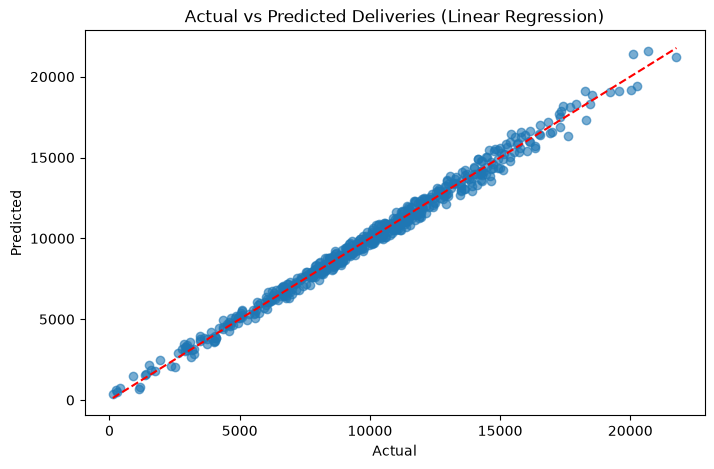

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Deliveries (Linear Regression)")

plt.show()

>The Actual vs Predicted scatter plot, with the red dashed line representing perfect prediction, shows how closely the Linear Regression predictions track the true delivery values. Points close to the diagonal indicate accurate predictions.

# 5-Fold Cross Validation

In [19]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(cv_scores)
print("Mean:", cv_scores.mean())
print("Std:", cv_scores.std())

[0.99064898 0.99046596 0.98949291 0.99051101 0.99080587]
Mean: 0.9903849476659861
Std: 0.0004615353092553957


>Five-fold cross validation was performed to evaluate model stability and generalization performance. The dataset was divided into five subsets, with each subset serving as a validation set once. The mean R² score and standard deviation indicate how consistently the model performs across different partitions of the data.

# Random Forest and GridSearchCV

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information prin

In [21]:
print(grid.best_params_)

{'max_depth': None, 'n_estimators': 50}


**Prediction:**

In [22]:
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest R2: 0.99015903323468


>A Random Forest Regressor was tuned using GridSearchCV across combinations of n_estimators and max_depth. The best-performing configuration was selected automatically based on 5-fold cross-validated R².

>Comparing the Random Forest R² to the Linear Regression R² above shows how the two model families perform relative to each other on this dataset.

# Top 10 Feature Importances

In [23]:
imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

imp = imp.sort_values(by='Importance', ascending=False)

top10 = imp.head(10)
top10

,Feature,Importance
4,Production_Units,0.990055
8,CO2_Saved_tons,0.002163
7,Range_km,0.001221
5,Avg_Price_USD,0.001040
10,Charging_Stations,0.001004
12,Rolling_Mean_3,0.000955
11,Deliveries_Lag1,0.000923
0,Year,0.000888
1,Month,0.000668
3,Model,0.000357


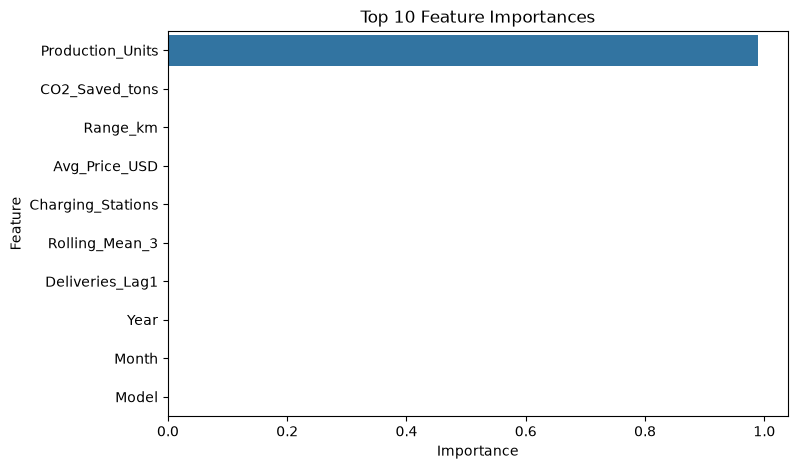

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances")
plt.show()

In [25]:
print("Correlation between Production_Units and Estimated_Deliveries:")
print(df['Production_Units'].corr(df['Estimated_Deliveries']))

Correlation between Production_Units and Estimated_Deliveries:
0.9942343488939529


>Feature importance analysis reveals which variables are most influential in predicting Estimated_Deliveries. As expected, Production_Units and the engineered lag/rolling features tend to dominate, consistent with the strong correlation observed in the heatmap.

# ADF Test (Stationarity Check)

In [26]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -53.82661259715622
p-value: 0.0


In [27]:
if result[1] < 0.05:
    print("Stationary")
else:
    print("Non-stationary")

Stationary


>The Augmented Dickey-Fuller (ADF) test was performed on the Estimated_Deliveries series to check for stationarity. If the p-value is below the 0.05 significance level, the null hypothesis of non-stationarity is rejected, indicating the series does not exhibit a unit root and is suitable for several time-series forecasting techniques without differencing.

# Forecast Comparison Table

In [28]:
forecast = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_pred
})

forecast['Error_%'] = (
    abs(forecast['Actual'] - forecast['Predicted']) / forecast['Actual']
) * 100

forecast.head(20)

,Actual,Predicted,Error_%
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


In [29]:
print("Average forecast error (%):", forecast['Error_%'].mean())
print("Max forecast error (%):", forecast['Error_%'].max())

Average forecast error (%): 3.214832768367409
Max forecast error (%): 21.609374999999996


>The forecast comparison table presents actual vs. predicted delivery values from the held-out test set, along with the percentage error for each prediction. Lower average error percentages indicate that the Random Forest model captures the relationship between production, pricing, battery capacity, and other features effectively enough to produce reliable delivery forecasts.

# Conclusion

This project built an end-to-end machine learning pipeline on Tesla delivery and production data from 2015–2025, covering data cleaning, exploratory data analysis, feature engineering (label encoding, lag features, rolling means), regression modeling (Linear Regression and Random Forest with GridSearchCV hyperparameter tuning), and time series diagnostics (the ADF stationarity test). Strong relationships were observed between Production_Units and Estimated_Deliveries, both in the correlation analysis and in feature importance rankings. The resulting models and forecast comparison table demonstrate that machine learning methods can effectively capture and forecast Tesla's delivery trends across regions and models.